In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
df = pd.read_csv("Housing.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

df = df.dropna()

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

In [4]:
le = LabelEncoder()

categorical_cols = ['mainroad', 'guestroom', 'basement',
                    'hotwaterheating', 'airconditioning',
                     'prefarea', 'furnishingstatus']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df[['area',
        'bedrooms',
        'bathrooms',
        'stories',
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'parking',
        'prefarea',
        'furnishingstatus']]

y = df['price']

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
print("\nR2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)



R2 Score: 0.6494754192267793
Mean Absolute Error: 979679.6912959907
Intercept: 4706527.385321101
Coefficients: [ 519288.13010471   58690.91849754  523153.38284253  348177.1136099
  128115.92797751   89357.64620755  188462.04856579  150570.02827934
  362446.18646599  192786.98589143  266661.04914928 -158183.27016874]


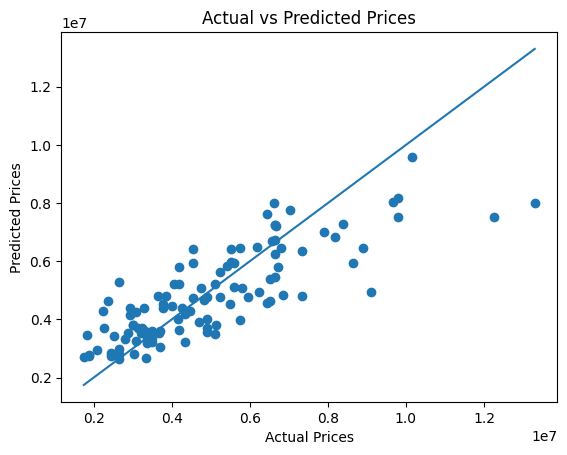

In [9]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)])

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()